<a href="https://colab.research.google.com/github/Wendie71/Book-Recommendation-System/blob/main/Bookrecommendationsystem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors

import warnings
warnings.filterwarnings("ignore")

In [3]:
from google.colab import files
uploaded = files.upload()
from google.colab import files
uploaded = files.upload()
from google.colab import files
uploaded = files.upload()

Saving books.csv to books (1).csv


Saving ratings.csv to ratings (1).csv


Saving users.csv to users.csv


In [5]:
books = pd.read_csv(
    "books (1).csv",
    sep=";",
    encoding="latin-1",
    on_bad_lines="skip"
)

ratings = pd.read_csv(
    "ratings (1).csv",
    sep=";",
    encoding="latin-1",
    on_bad_lines="skip"
)

users = pd.read_csv(
    "users.csv",
    sep=";",
    encoding="latin-1",
    on_bad_lines="skip"
)

In [6]:
print("Books Shape:", books.shape)
print("Ratings Shape:", ratings.shape)
print("Users Shape:", users.shape)

books.head()
ratings.head()
users.head()

Books Shape: (271360, 8)
Ratings Shape: (1149780, 3)
Users Shape: (278858, 3)


,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [7]:
books.columns = [
    'ISBN',
    'Book_Title',
    'Book_Author',
    'Year_Of_Publication',
    'Publisher',
    'Image_URL_S',
    'Image_URL_M',
    'Image_URL_L'
]

ratings.columns = [
    'User_ID',
    'ISBN',
    'Book_Rating'
]

users.columns = [
    'User_ID',
    'Location',
    'Age'
]

In [9]:
#checking for missing values
print(books.isnull().sum())
print(users.isnull().sum())
print(ratings.isnull().sum())

ISBN                   0
Book_Title             0
Book_Author            2
Year_Of_Publication    0
Publisher              2
Image_URL_S            0
Image_URL_M            0
Image_URL_L            3
dtype: int64
User_ID          0
Location         0
Age         110762
dtype: int64
User_ID        0
ISBN           0
Book_Rating    0
dtype: int64


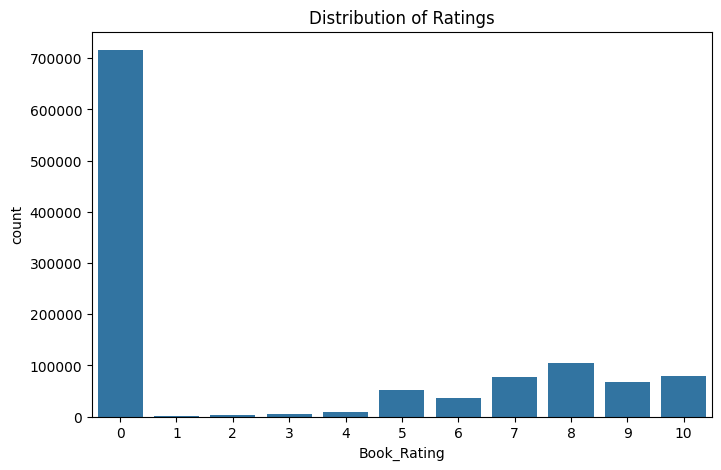

In [12]:
#explanatory Data analysis
plt.figure(figsize=(8,5))
sns.countplot(x='Book_Rating', data=ratings)
plt.title("Distribution of Ratings")
plt.show()

In [14]:
#Most rated books
popular_books = ratings.groupby('ISBN').count()['Book_Rating']\
                        .reset_index()

popular_books.rename(
    columns={'Book_Rating':'Num_Ratings'},
    inplace=True
)

popular_books.head()

,ISBN,Num_Ratings
0,0330299891,2
1,0375404120,2
2,0586045007,1
3,9022906116,2
4,9032803328,1


In [16]:
#Merging books and ratings
ratings_with_books = ratings.merge(
    books,
    on='ISBN'
)

ratings_with_books.head()

,User_ID,ISBN,Book_Rating,Book_Title,Book_Author,Year_Of_Publication,Publisher,Image_URL_S,Image_URL_M,Image_URL_L
0,276725,034545104X,0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...
1,276726,0155061224,5,Rites of Passage,Judith Rae,2001,Heinle,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...
2,276727,0446520802,0,The Notebook,Nicholas Sparks,1996,Warner Books,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...
3,276729,052165615X,3,Help!: Level 1,Philip Prowse,1999,Cambridge University Press,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...
4,276729,0521795028,6,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,2001,Cambridge University Press,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...


In [17]:
#Calculating Number of ratings per books
book_rating_count = ratings_with_books.groupby(
    'Book_Title'
)['Book_Rating'].count().reset_index()

book_rating_count.rename(
    columns={'Book_Rating':'Num_Ratings'},
    inplace=True
)

book_rating_count.head()

,Book_Title,Num_Ratings
0,A Light in the Storm: The Civil War Diary of ...,4
1,Always Have Popsicles,1
2,Apple Magic (The Collector's series),1
3,"Ask Lily (Young Women of Faith: Lily Series, ...",1
4,Beyond IBM: Leadership Marketing and Finance ...,1


In [18]:
final_df = ratings_with_books.merge(
    book_rating_count,
    on='Book_Title'
)

final_df.head()

,User_ID,ISBN,Book_Rating,Book_Title,Book_Author,Year_Of_Publication,Publisher,Image_URL_S,Image_URL_M,Image_URL_L,Num_Ratings
0,276725,034545104X,0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,60
1,276726,0155061224,5,Rites of Passage,Judith Rae,2001,Heinle,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,14
2,276727,0446520802,0,The Notebook,Nicholas Sparks,1996,Warner Books,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,650
3,276729,052165615X,3,Help!: Level 1,Philip Prowse,1999,Cambridge University Press,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,1
4,276729,0521795028,6,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,2001,Cambridge University Press,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,1


In [20]:
#Kepping the most popular books
final_df = final_df[
    final_df['Num_Ratings'] >= 50
]

In [21]:
active_users = final_df.groupby(
    'User_ID'
)['Book_Rating'].count()

active_users = active_users[
    active_users >= 100
].index

final_df = final_df[
    final_df['User_ID'].isin(active_users)
]

In [22]:
user_book_matrix = final_df.pivot_table(
    index='Book_Title',
    columns='User_ID',
    values='Book_Rating'
)

In [23]:
#filling missing values
user_book_matrix.fillna(
    0,
    inplace=True
)

user_book_matrix.head()

User_ID,3363,6251,6543,6563,6575,7158,7346,8245,8253,8936,...,271448,271705,273979,274004,274061,274301,274308,275970,277427,278418
Book_Title,,,,,,,,,,,,,,,,,,,,,
10 Lb. Penalty,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16 Lighthouse Road,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1984,0.0,0.0,0.0,0.0,0.0,0.0,8.0,0.0,0.0,0.0,...,0.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1st to Die: A Novel,0.0,0.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2010: Odyssey Two,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [24]:
sparse_matrix = csr_matrix(
    user_book_matrix
)

In [25]:
#Training KNN model
model = NearestNeighbors(
    algorithm='brute',
    metric='cosine'
)

model.fit(sparse_matrix)

NearestNeighbors(algorithm='brute', metric='cosine')

In [26]:
def recommend_books(book_name):

    if book_name not in user_book_matrix.index:
        print("Book not found.")
        return

    book_index = user_book_matrix.index.get_loc(
        book_name
    )

    distances, suggestions = model.kneighbors(
        user_book_matrix.iloc[
            book_index,:].values.reshape(1,-1),
        n_neighbors=6
    )

    print("\nRecommended Books:\n")

    for i in range(
        1,
        len(suggestions[0])
    ):
        print(
            user_book_matrix.index[
                suggestions[0][i]
            ]
        )

In [28]:
#Testing recommendation
recommend_books(
    "Harry Potter and the Chamber of Secrets (Book 2)"
)


Recommended Books:

Harry Potter and the Prisoner of Azkaban (Book 3)
Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback))
Harry Potter and the Goblet of Fire (Book 4)
Harry Potter and the Sorcerer's Stone (Book 1)
Charlotte's Web (Trophy Newbery)


In [29]:
import pickle

pickle.dump(
    model,
    open("book_recommender.pkl","wb")
)

pickle.dump(
    user_book_matrix,
    open("book_matrix.pkl","wb")
)

In [30]:
model = pickle.load(
    open("book_recommender.pkl","rb")
)

user_book_matrix = pickle.load(
    open("book_matrix.pkl","rb")
)

In [41]:
%%writefile app.py
!pip install streamlit

import streamlit as st
import pickle
import pandas as pd

# Load model and matrix
model = pickle.load(
    open("book_recommender.pkl", "rb")
)

user_book_matrix = pickle.load(
    open("book_matrix.pkl", "rb")
)
book_cover_dict = pickle.load(
    open(
        "book_covers.pkl",
        "rb"
    )
)

# Recommendation function
def recommend_books(book_name):

    if book_name not in user_book_matrix.index:
        return []

    book_index = user_book_matrix.index.get_loc(
        book_name
    )

    distances, suggestions = model.kneighbors(
        user_book_matrix.iloc[
            book_index, :
        ].values.reshape(1, -1),
        n_neighbors=6
    )

    recommendations = []

    for i in range(
        1,
        len(suggestions[0])
    ):
        recommendations.append(
            user_book_matrix.index[
                suggestions[0][i]
            ]
        )

    return recommendations


# Page configuration
st.set_page_config(
    page_title="Book Recommendation System",
    page_icon="📚",
    layout="centered"
)

# Title
st.title("📚 Book Recommendation System")

st.markdown(
    """
    Select a book you have enjoyed and get
    personalized recommendations.
    """
)

# Dropdown
selected_book = st.selectbox(
    "Choose a Book",
    sorted(user_book_matrix.index)
)

# Button
if st.button("Recommend Books"):

    recommendations = recommend_books(
        selected_book
    )

    st.subheader(
        "Recommended Books"
    )

    for book in recommendations:

        col1, col2 = st.columns([1,3])

        with col1:
            st.image(
                book_cover_dict.get(book),
                width=100
            )

        with col2:
            st.write(book)

Writing app.py


In [35]:
books[['ISBN',
       'Book_Title',
       'Image_URL_L']]

,ISBN,Book_Title,Image_URL_L
0,0195153448,Classical Mythology,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,http://images.amazon.com/images/P/0393045218.0...
...,...,...,...
271355,0440400988,There's a Bat in Bunk Five,http://images.amazon.com/images/P/0440400988.0...
271356,0525447644,From One to One Hundred,http://images.amazon.com/images/P/0525447644.0...
271357,006008667X,Lily Dale : The True Story of the Town that Ta...,http://images.amazon.com/images/P/006008667X.0...
271358,0192126040,Republic (World's Classics),http://images.amazon.com/images/P/0192126040.0...


In [36]:
book_cover_dict = books.set_index(
    'Book_Title'
)['Image_URL_L'].to_dict()

In [37]:
import pickle

pickle.dump(
    book_cover_dict,
    open(
        "book_covers.pkl",
        "wb"
    )
)

In [38]:
book_cover_dict = pickle.load(
    open(
        "book_covers.pkl",
        "rb"
    )
)

In [43]:
#creating requirements.txt
%%writefile requirements.txt
streamlit
pandas
numpy
scikit-learn
scipy

Overwriting requirements.txt


In [44]:
!ls

 app.py		   book_recommender.pkl  'ratings (1).csv'   sample_data
 book_covers.pkl  'books (1).csv'	  ratings.csv	     users.csv
 book_matrix.pkl   books.csv		  requirements.txt


In [45]:
#Downloading my files before deployment on render
from google.colab import files
files.download("book_recommender.pkl")
files.download("book_matrix.pkl")
files.download("book_covers.pkl")
files.download("app.py")
files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>